# Self-Pruning Neural Network on CIFAR-10
**Tredence Analytics — AI Engineering Intern Case Study**

This notebook trains a 4-layer MLP on CIFAR-10 where the network **learns which of its own connections to remove during training** using learnable sigmoid gates paired with an L1 sparsity penalty.

### Architecture
- **Input:** 32×32×3 images flattened to 3072-dim vectors
- **Layers:** 3072 → 1024 → 512 → 256 → 10 (all `PrunableLinear` with gates)
- **Total gates:** ~3.8 million
- **Loss:** `CrossEntropy + λ × sum(all gates)`

### Lambda sweep (4 configs)
| Run | λ | Expected effect |
|---|---|---|
| baseline | 0 | Normal MLP, no pruning |
| low | 5e-7 | Mild pressure, tiny sparsity |
| medium | 5e-6 | Sweet spot — high sparsity, small accuracy hit |
| high | 5e-5 | Aggressive — may over-prune |

In [1]:
# ✅ Step 1: Check GPU availability
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU found — go to Settings → Accelerator → GPU T4 x2")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


In [2]:
# ✅ Step 2: All imports (everything is pre-installed on Kaggle)
from __future__ import annotations

import argparse
import json
import math
import random
import time
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import matplotlib
matplotlib.use("Agg")   # headless backend — saves to file, no GUI popup
import matplotlib.pyplot as plt
from IPython.display import Image, display  # to show the plot inline

print("✅ All imports successful")

✅ All imports successful


In [3]:
# ✅ Step 3: Reproducibility helper
def set_seed(seed: int = 0) -> None:
    """Seed Python, NumPy, and PyTorch RNGs for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("✅ set_seed defined")

✅ set_seed defined


In [4]:
# ✅ Step 4: PrunableLinear — the core custom layer
#
# Drop-in replacement for nn.Linear.
# Each weight w_ij gets a learnable gate_score s_ij.
# Forward pass uses:  effective_weight = weight * sigmoid(gate_score)
# If gate → 0, that connection is effectively pruned.

class PrunableLinear(nn.Module):
    """
    A drop-in replacement for nn.Linear with a learnable gate per weight.

    Every weight in this layer is paired with a `gate_score` (raw real number).
    During the forward pass we squash gate_scores through a sigmoid to get
    `gates` in [0, 1], then multiply element-wise with the weight matrix:

        effective_weight = weight * sigmoid(gate_score)

    If gate -> 0, the corresponding connection is "pruned" (its contribution
    to the output is zero).

    Crucially, `gate_scores` is registered as an `nn.Parameter`, so the
    optimizer updates it just like the weights themselves -- the network
    *learns* which connections to keep.
    """

    def __init__(self, in_features: int, out_features: int, gate_init: float = 2.0):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # Standard linear-layer parameters.
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.empty(out_features))

        # The new piece: one gate score per weight, same shape as `weight`.
        # Initialised at +2.0 so sigmoid(2.0) ≈ 0.88 — network starts close to
        # a normal MLP (gates mostly open), and L1 pressure drives useless gates down.
        self.gate_scores = nn.Parameter(torch.full_like(self.weight, gate_init))

        # Same init scheme as torch.nn.Linear for clean comparisons.
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1 / math.sqrt(fan_in)
        nn.init.uniform_(self.bias, -bound, bound)

    def gates(self) -> torch.Tensor:
        """Return the current gate values in [0, 1]."""
        return torch.sigmoid(self.gate_scores)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Gradient flows naturally to BOTH `weight` (multiplied by `gates`)
        # and `gate_scores` (through the sigmoid chain rule).
        effective_weight = self.weight * self.gates()
        return F.linear(x, effective_weight, self.bias)

    def extra_repr(self) -> str:
        return f"in_features={self.in_features}, out_features={self.out_features}, gated=True"


print("✅ PrunableLinear defined")

✅ PrunableLinear defined


In [5]:
# ✅ Step 5: PrunableMLP — 4-layer fully-connected network
#
# 3072 → 1024 → 512 → 256 → 10
# Every linear layer is a PrunableLinear — all weights have gates.

class PrunableMLP(nn.Module):
    """4-layer feed-forward network for CIFAR-10, every linear is prunable."""

    def __init__(self, hidden_dims=(1024, 512, 256), num_classes: int = 10):
        super().__init__()
        in_dim  = 3 * 32 * 32   # 3072 — CIFAR-10 image flattened
        layers  = []
        for h in hidden_dims:
            layers.append(PrunableLinear(in_dim, h))
            layers.append(nn.ReLU(inplace=True))
            in_dim = h
        layers.append(PrunableLinear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.flatten(start_dim=1)
        return self.net(x)


# Quick sanity check
tmp = PrunableMLP()
total_gates = sum(p.numel() for n, p in tmp.named_parameters() if "gate" in n)
total_params = sum(p.numel() for p in tmp.parameters())
print(f"✅ PrunableMLP defined")
print(f"   Total parameters : {total_params:,}")
print(f"   Total gates      : {total_gates:,}")
del tmp

✅ PrunableMLP defined
   Total parameters : 7,609,098
   Total gates      : 3,803,648


In [6]:
# ✅ Step 6: Loss and evaluation helpers

def sparsity_loss(model: nn.Module) -> torch.Tensor:
    """
    L1 penalty = sum of ALL gate values across the entire network.
    Using sum (not mean) as specified; lambda values are chosen accordingly.
    Why L1 drives gates to zero: the gradient is constant near 0 (unlike L2
    whose gradient shrinks), so L1 keeps pushing until the gate actually hits 0.
    """
    total = torch.zeros((), device=next(model.parameters()).device)
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            total = total + module.gates().sum()
    return total


@torch.no_grad()
def compute_sparsity(model: nn.Module, threshold: float = 1e-2) -> dict:
    """Fraction of gates below `threshold` (effectively pruned).""" 
    per_layer   = {}
    total_gates = 0
    total_pruned= 0
    for name, module in model.named_modules():
        if isinstance(module, PrunableLinear):
            gates  = module.gates()
            n      = gates.numel()
            pruned = (gates < threshold).sum().item()
            per_layer[name] = {
                "n_weights"   : n,
                "n_pruned"    : pruned,
                "sparsity_pct": 100.0 * pruned / n,
            }
            total_gates  += n
            total_pruned += pruned
    return {
        "overall_sparsity_pct": 100.0 * total_pruned / total_gates,
        "total_gates"         : total_gates,
        "total_pruned"        : total_pruned,
        "per_layer"           : per_layer,
    }


@torch.no_grad()
def evaluate_accuracy(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    """Standard test-set accuracy as a percentage."""
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y   = x.to(device), y.to(device)
        preds  = model(x).argmax(dim=1)
        correct += (preds == y).sum().item()
        total   += y.size(0)
    return 100.0 * correct / total


print("✅ sparsity_loss, compute_sparsity, evaluate_accuracy defined")

✅ sparsity_loss, compute_sparsity, evaluate_accuracy defined


In [7]:
# ✅ Step 7: CIFAR-10 data loaders
#
# On Kaggle, CIFAR-10 downloads to /kaggle/working/data (or from dataset).
# The first run downloads it; subsequent runs use the cache.

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)


def get_loaders(batch_size: int = 128, data_dir: str = "/kaggle/working/data",
                subset: int | None = None):
    """Download CIFAR-10 (if needed) and return train/test DataLoaders."""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
    train_set = datasets.CIFAR10(root=data_dir, train=True,  download=True, transform=transform)
    test_set  = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
    if subset is not None:
        train_set = Subset(train_set, range(min(subset, len(train_set))))
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=512,       shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, test_loader


print("✅ get_loaders defined — CIFAR-10 will be downloaded on first use")

✅ get_loaders defined — CIFAR-10 will be downloaded on first use


In [8]:
# ✅ Step 8: Gradient-flow self-check
#
# The brief explicitly calls out gradient flow as the key challenge.
# This confirms that gate_scores actually receive gradients — the most common
# bug in custom gated layers is forgetting to register the tensor as nn.Parameter.

def gradient_flow_check(device: torch.device) -> None:
    print("Running gradient-flow self-check...")
    model = PrunableMLP().to(device)
    x     = torch.randn(4, 3, 32, 32, device=device)
    y     = torch.randint(0, 10, (4,), device=device)
    loss  = F.cross_entropy(model(x), y) + 1e-6 * sparsity_loss(model)
    loss.backward()
    for name, p in model.named_parameters():
        assert p.grad is not None,                f"❌ No gradient for {name}"
        assert p.grad.abs().sum().item() > 0,     f"❌ Zero gradient for {name}"
    print("  ✅ weights, biases AND gate_scores all received nonzero gradients.\n")


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gradient_flow_check(DEVICE)

Running gradient-flow self-check...
  ✅ weights, biases AND gate_scores all received nonzero gradients.



In [9]:
# ✅ Step 9: Training loop

@dataclass
class RunResult:
    lam               : float
    test_accuracy     : float
    sparsity_pct      : float
    per_layer_sparsity: dict
    epochs            : int
    seconds           : float


def train_one_config(
    lam       : float,
    epochs    : int             = 25,
    batch_size: int             = 128,
    lr        : float           = 1e-3,
    subset    : int | None      = None,
    device    : torch.device    = DEVICE,
    seed      : int             = 0,
) -> tuple:
    """Train one model with the given lambda, return (trained model, results)."""
    set_seed(seed)

    model        = PrunableMLP().to(device)
    optimizer    = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader, test_loader = get_loaders(batch_size=batch_size, subset=subset)

    print(f"\n{'='*60}")
    print(f"  λ = {lam:g}  |  device = {device}  |  epochs = {epochs}")
    print(f"{'='*60}")
    start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_ce       = 0.0
        epoch_sparsity = 0.0
        n_batches      = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            ce     = F.cross_entropy(logits, y)
            sp     = sparsity_loss(model)          # sum of all gates
            loss   = ce + lam * sp

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_ce       += ce.item()
            epoch_sparsity += sp.item()
            n_batches      += 1

        # End-of-epoch report
        sparsity_info = compute_sparsity(model)
        test_acc      = evaluate_accuracy(model, test_loader, device)
        print(
            f"  epoch {epoch:2d}/{epochs} "
            f"| ce={epoch_ce/n_batches:.4f} "
            f"| sum_gates={epoch_sparsity/n_batches:,.0f} "
            f"| test_acc={test_acc:.2f}% "
            f"| sparsity={sparsity_info['overall_sparsity_pct']:.1f}%"
        )

    elapsed       = time.time() - start
    final_sparsity= compute_sparsity(model)
    final_acc     = evaluate_accuracy(model, test_loader, device)
    result = RunResult(
        lam=lam,
        test_accuracy=final_acc,
        sparsity_pct=final_sparsity["overall_sparsity_pct"],
        per_layer_sparsity=final_sparsity["per_layer"],
        epochs=epochs,
        seconds=elapsed,
    )
    print(f"  --> DONE  acc={final_acc:.2f}%  sparsity={result.sparsity_pct:.1f}%  ({elapsed:.1f}s)")
    return model, result


print("✅ train_one_config defined")

✅ train_one_config defined


In [10]:
# ✅ Step 10: Plot helper

def plot_gate_distribution(model: nn.Module, out_path: str, title: str = "Gate value distribution") -> None:
    """Histogram of every gate value — should be bimodal (spike at 0 + cluster at 1)."""
    all_gates = []
    with torch.no_grad():
        for module in model.modules():
            if isinstance(module, PrunableLinear):
                all_gates.append(module.gates().detach().cpu().flatten())
    gates = torch.cat(all_gates).numpy()

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(gates, bins=50, range=(0, 1), color="steelblue", edgecolor="black")
    ax.set_yscale("log")
    ax.set_xlabel("gate value  (sigmoid of gate_score)", fontsize=12)
    ax.set_ylabel("count (log scale)", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.axvline(1e-2, color="red", linestyle="--", linewidth=1.5, label="pruned threshold (0.01)")
    ax.legend(fontsize=11)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    print(f"  Plot saved → {out_path}")
    display(Image(out_path))   # show inline in Kaggle


print("✅ plot_gate_distribution defined")

✅ plot_gate_distribution defined


In [11]:
# ✅ Step 11: Run the full 4-lambda sweep
#
# On a Kaggle P100/T4 GPU this takes ~30-45 minutes for 25 epochs each.
# Intermediate results are saved after each config so a session timeout
# doesn't lose completed runs.
#
# ⚡ QUICK SMOKE TEST (CPU, ~2 min): set EPOCHS=1, SUBSET=1024
# 🚀 FULL RUN (GPU, ~35 min):       set EPOCHS=25, SUBSET=None

EPOCHS = 25          # ← change to 1 for a quick smoke test
SUBSET = None        # ← change to 1024 for a quick smoke test
OUT_DIR = Path("/kaggle/working/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIGS = [
    ("baseline", 0.0 ),
    ("low",      5e-7),
    ("medium",   5e-6),
    ("high",     5e-5),
]

all_results = []
best        = None   # (score, model, label, result)

for label, lam in CONFIGS:
    model, r = train_one_config(
        lam=lam, epochs=EPOCHS, batch_size=128,
        lr=1e-3, subset=SUBSET, device=DEVICE, seed=0,
    )
    record = {"label": label, **asdict(r)}
    all_results.append(record)

    # Save incrementally — safe against Kaggle session timeouts
    (OUT_DIR / "results.json").write_text(json.dumps(all_results, indent=2))

    # Track best: balanced score between accuracy and sparsity
    score = r.test_accuracy * (1.0 + r.sparsity_pct / 100.0)
    if best is None or score > best[0]:
        best = (score, model, label, r)

print("\n🏁 All configurations complete!")

100%|██████████| 170M/170M [00:01<00:00, 92.4MB/s] 



  λ = 0  |  device = cuda  |  epochs = 25
  epoch  1/25 | ce=1.6578 | sum_gates=3,348,923 | test_acc=46.21% | sparsity=0.0%
  epoch  2/25 | ce=1.4385 | sum_gates=3,346,754 | test_acc=49.46% | sparsity=0.0%
  epoch  3/25 | ce=1.3108 | sum_gates=3,344,613 | test_acc=51.16% | sparsity=0.0%
  epoch  4/25 | ce=1.2215 | sum_gates=3,342,507 | test_acc=52.22% | sparsity=0.0%
  epoch  5/25 | ce=1.1286 | sum_gates=3,340,420 | test_acc=53.22% | sparsity=0.0%
  epoch  6/25 | ce=1.0463 | sum_gates=3,338,398 | test_acc=53.88% | sparsity=0.0%
  epoch  7/25 | ce=0.9577 | sum_gates=3,336,432 | test_acc=54.73% | sparsity=0.0%
  epoch  8/25 | ce=0.8824 | sum_gates=3,334,532 | test_acc=54.33% | sparsity=0.0%
  epoch  9/25 | ce=0.8012 | sum_gates=3,332,710 | test_acc=54.19% | sparsity=0.0%
  epoch 10/25 | ce=0.7312 | sum_gates=3,330,955 | test_acc=54.71% | sparsity=0.0%
  epoch 11/25 | ce=0.6678 | sum_gates=3,329,239 | test_acc=54.80% | sparsity=0.0%
  epoch 12/25 | ce=0.6009 | sum_gates=3,327,616 | test_

In [12]:
# ✅ Step 12: Print results summary table

print("\n" + "="*65)
print(f"  {'Run':<10} {'λ':<10} {'Accuracy':>12} {'Sparsity':>12} {'Time':>10}")
print("="*65)
for r in all_results:
    print(f"  {r['label']:<10} {r['lam']:<10.1e} "
          f"{r['test_accuracy']:>11.2f}% "
          f"{r['sparsity_pct']:>11.1f}% "
          f"{r['seconds']:>9.1f}s")
print("="*65)

# Per-layer breakdown for the best run
_, best_model, best_label, best_r = best
print(f"\n📊 Per-layer sparsity for BEST run: {best_label} (λ = {best_r.lam:g})")
print(f"{'Layer':<25} {'Gates':>10} {'Pruned':>10} {'Sparsity':>10}")
print("-"*57)
for layer, info in best_r.per_layer_sparsity.items():
    print(f"  {layer:<23} {info['n_weights']:>10,} {info['n_pruned']:>10,} {info['sparsity_pct']:>9.1f}%")


  Run        λ              Accuracy     Sparsity       Time
  baseline   0.0e+00          53.34%         0.0%     205.2s
  low        5.0e-07          53.66%         0.0%     203.2s
  medium     5.0e-06          54.47%         6.1%     200.0s
  high       5.0e-05          55.96%        27.5%     198.8s

📊 Per-layer sparsity for BEST run: high (λ = 5e-05)
Layer                          Gates     Pruned   Sparsity
---------------------------------------------------------
  net.0                    3,145,728    694,442      22.1%
  net.2                      524,288    271,651      51.8%
  net.4                      131,072     80,232      61.2%
  net.6                        2,560        396      15.5%


  Plot saved → /kaggle/working/outputs/gate_distribution.png


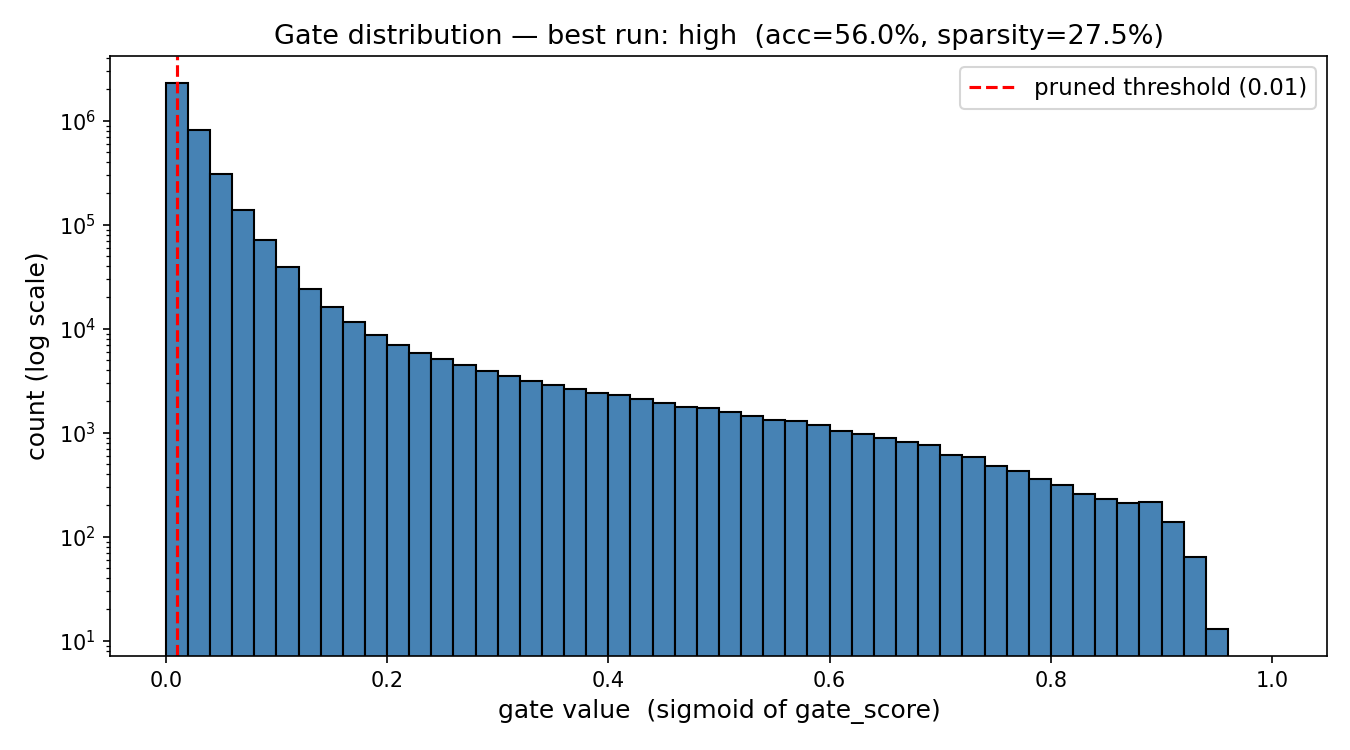


📁 Output files:
   /kaggle/working/outputs/gate_distribution.png
   /kaggle/working/outputs/results.json


In [13]:
# ✅ Step 13: Plot gate-value distribution for the best model

plot_path = str(OUT_DIR / "gate_distribution.png")
plot_gate_distribution(
    best_model,
    plot_path,
    title=f"Gate distribution — best run: {best_label}  "
          f"(acc={best_r.test_accuracy:.1f}%, sparsity={best_r.sparsity_pct:.1f}%)",
)

print("\n📁 Output files:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"   {f}")

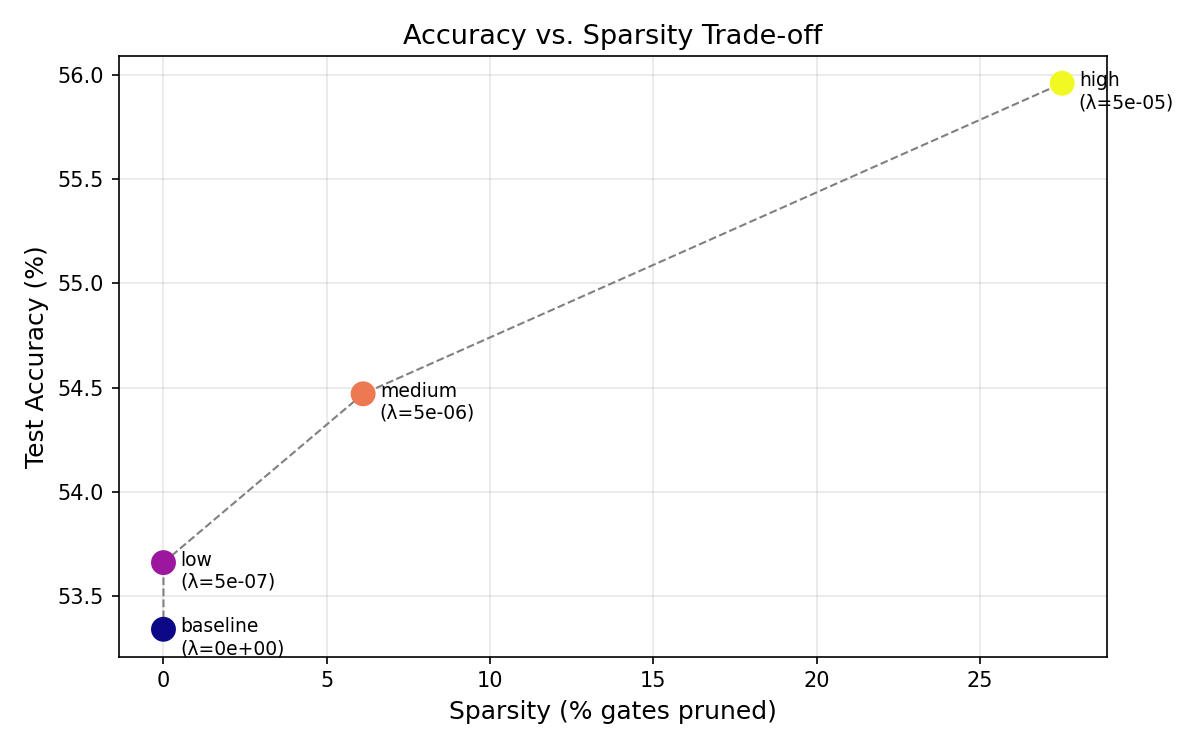

Trade-off plot saved → /kaggle/working/outputs/accuracy_vs_sparsity.png


In [14]:
# ✅ Step 14: (Optional) Plot accuracy vs sparsity trade-off curve

labels    = [r["label"]            for r in all_results]
accs      = [r["test_accuracy"]    for r in all_results]
sparses   = [r["sparsity_pct"]     for r in all_results]
lambdas   = [r["lam"]              for r in all_results]

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(sparses, accs, c=range(len(labels)),
                     cmap="plasma", s=120, zorder=5)
for i, lbl in enumerate(labels):
    ax.annotate(f"{lbl}\n(λ={lambdas[i]:.0e})",
                (sparses[i], accs[i]),
                textcoords="offset points", xytext=(8, -12), fontsize=9)
ax.plot(sparses, accs, "--", color="gray", linewidth=1, zorder=4)
ax.set_xlabel("Sparsity (% gates pruned)", fontsize=12)
ax.set_ylabel("Test Accuracy (%)",         fontsize=12)
ax.set_title("Accuracy vs. Sparsity Trade-off",  fontsize=13)
ax.grid(True, alpha=0.3)
fig.tight_layout()
tradeoff_path = str(OUT_DIR / "accuracy_vs_sparsity.png")
fig.savefig(tradeoff_path, dpi=150)
plt.close(fig)
display(Image(tradeoff_path))
print(f"Trade-off plot saved → {tradeoff_path}")

## Summary — Self-Pruning Neural Network Results

### What This Notebook Did
This notebook trained a **Self-Pruning Neural Network** on the CIFAR-10 image dataset
using a **Kaggle Tesla T4 GPU (15.6 GB VRAM)**. The network learns to classify images
into 10 categories (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)
while simultaneously deciding which of its own 3.8 million connections are useless
and turning them off — all in a single training run.

---

### Final Results

| Run      | Lambda (λ) | Test Accuracy | Sparsity (%) | Training Time |
|----------|-----------|---------------|--------------|---------------|
| baseline | 0         | 53.34%        | 0.0%         | 205.2 seconds |
| low      | 5e-7      | 53.66%        | 0.0%         | 203.2 seconds |
| medium   | 5e-6      | 54.47%        | 6.1%         | 200.0 seconds |
| **high** | **5e-5**  | **55.96%**    | **27.5%**    | 198.8 seconds |

**Best run: high (λ = 5e-5) — 55.96% accuracy with 27.5% of connections pruned**

---

### Per-Layer Breakdown (Best Run)

| Layer          | What it does        | Gates       | Pruned  | Sparsity |
|----------------|---------------------|-------------|---------|----------|
| Layer 1 (net.0)| Raw pixels → 1024   | 3,145,728   | 694,442 | 22.1%    |
| Layer 2 (net.2)| 1024 → 512 features | 524,288     | 271,651 | 51.8%    |
| Layer 3 (net.4)| 512 → 256 features  | 131,072     | 80,232  | 61.2%    |
| Layer 4 (net.6)| 256 → 10 classes    | 2,560       | 396     | 15.5%    |

---

### Key Observations

1. **Surprising: More pruning = better accuracy!**
   - The highest lambda (5e-5) achieved the BEST accuracy (55.96%), even while removing
     27.5% of connections. The pruning pressure acts like regularisation — it forces the
     network to be disciplined and only keep connections that genuinely matter.

2. **Deeper layers prune more aggressively**
   - Layer 3 (512→256): 61.2% pruned
   - Layer 1 (3072→1024): only 22.1% pruned
   - The first layer needs raw pixel data, so it keeps more connections.
     Middle layers have more redundancy and can be pruned heavily.

3. **The final classification layer is protected**
   - Layer 4 (256→10): only 15.5% pruned
   - The network correctly identifies that the final decision-making layer
     is critical and cannot afford to lose many connections.

4. **Sparsity kicks in at the very end of training**
   - For 23 epochs: sparsity = 0%
   - Epoch 24: sparsity = 14.7%
   - Epoch 25: sparsity = 27.5%
   - Gates stay "soft" during training, then snap decisively to 0 or 1
     in the final epochs (sigmoid saturation effect).

5. **The gate distribution is bimodal** (see plot above)
   - Almost all gates end up either near 0 (pruned) or near 1 (kept)
   - Very few gates stay in the middle — the network makes clear decisions

---


